In [171]:
# ============================================================
# The Paradox of Happiness — Explainer Notebook
# DTU 02467 Social Graphs and Interactions (2026)
# ============================================================
# This notebook investigates how the World Happiness Index
# relates to income inequality (GINI), economic stability
# (unemployment), and mental-health interventions
# (antidepressant usage) across 2015-2020.
# ============================================================

import warnings
warnings.filterwarnings("ignore")

# ── Global colour palette (cluster colours) ─────────────────
# Defined here so every section can reference it consistently,
# regardless of execution order. Supports up to 8 clusters.
cluster_colors = [
    "#636EFA", "#EF553B", "#00CC96",
    "#AB63FA", "#FFA15A", "#19D3F3",
    "#FF6692", "#B6E880",
]
# ── end of setup cell ────────────────────────────────────────

# 1. Motivation

**Research Question:** *Is happiness real — or is it medicated?*

We investigate the "Paradox of Happiness" by exploring how the World Happiness Index relates to income inequality (GINI Index), economic stability (unemployment rate), and mental-health interventions (antidepressant consumption) for the period **2015–2020**.

### Datasets
| # | Dataset | Source | Key Metric |
|---|---------|--------|------------|
| 1 | World Happiness Report | WHR / Kaggle | Happiness Score (0–10) |
| 2 | GINI Index | World Bank | Income inequality (0–100) |
| 3 | Unemployment Rate | World Bank (ILO est.) | % of labour force |
| 4 | Antidepressant Consumption | OECD | DDD per 1 000 inhabitants per day |

### User Experience Goal
A layperson should be able to explore an interactive bubble chart and discover, for instance, that some of the *happiest* countries also consume the *most* antidepressants — raising questions about what "happiness" really measures.

# 2. Basic Stats — Data Cleaning, Preprocessing & EDA

Below we load the four datasets, standardise country names, filter to 2015–2020, aggregate, and perform an inner join so that only countries with **all four variables** are retained.

## 2.1 — Inspect the Happiness Excel file
We first peek at the Happiness dataset to learn its column names and structure before writing the full loading pipeline.

In [172]:
import pandas as pd

# --- Inspect the Happiness Excel file ---
happiness_path = "./data/Happiness index 2011-2025.xlsx"
xls = pd.ExcelFile(happiness_path)
print("Sheet names:", xls.sheet_names)

# Read the first sheet and display structure
df_hap_raw = pd.read_excel(happiness_path, sheet_name=0)
print(f"\nShape: {df_hap_raw.shape}")
print(f"\nColumns:\n{list(df_hap_raw.columns)}")
print(f"\nDtypes:\n{df_hap_raw.dtypes}")
print(f"\nFirst 5 rows:")
df_hap_raw.head()

Sheet names: ['Data for Figure 2.1 (2011–2025)']

Shape: (2116, 13)

Columns:
['Year', 'Rank', 'Country name', 'Life evaluation (3-year average)', 'Lower whisker', 'Upper whisker', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of corruption', 'Dystopia + residual']

Dtypes:
Year                                            int64
Rank                                            int64
Country name                                      str
Life evaluation (3-year average)              float64
Lower whisker                                 float64
Upper whisker                                 float64
Explained by: Log GDP per capita              float64
Explained by: Social support                  float64
Explained by: Healthy life expectancy         float64
Explained by: Freedom to make life choices    float64
Explained by: Generos

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


## 2.2 — Load all datasets & filter to 2015–2020

In [173]:
import numpy as np

YEAR_MIN, YEAR_MAX = 2015, 2020

# ── 1) Happiness ────────────────────────────────────────────
df_hap = pd.read_excel(
    "./data/Happiness index 2011-2025.xlsx", sheet_name=0
)
df_hap = df_hap[["Country name", "Year", "Life evaluation (3-year average)"]].copy()
df_hap.columns = ["Country", "Year", "Happiness"]
df_hap = df_hap[(df_hap["Year"] >= YEAR_MIN) & (df_hap["Year"] <= YEAR_MAX)]
print(f"Happiness  : {df_hap.shape[0]} rows, {df_hap['Country'].nunique()} countries")

# ── 2) GINI Index (World Bank – wide format) ───────────────
df_gini_wide = pd.read_csv(
    "./data/GINI 2000-2024-25/API_SI.POV.GINI_DS2_en_csv_v2_288.csv",
    skiprows=4,
)
# Keep only country name + year columns for our range
year_cols = [str(y) for y in range(YEAR_MIN, YEAR_MAX + 1)]
df_gini = df_gini_wide[["Country Name"] + year_cols].copy()
df_gini = df_gini.melt(id_vars="Country Name", var_name="Year", value_name="GINI")
df_gini["Year"] = df_gini["Year"].astype(int)
df_gini.rename(columns={"Country Name": "Country"}, inplace=True)
df_gini.dropna(subset=["GINI"], inplace=True)
print(f"GINI       : {df_gini.shape[0]} rows, {df_gini['Country'].nunique()} countries")

# ── 3) Unemployment Rate (World Bank – wide format) ────────
df_unem_wide = pd.read_csv(
    "./data/Unemplyment rate 1991-2025/API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36.csv",
    skiprows=4,
)
df_unem = df_unem_wide[["Country Name"] + year_cols].copy()
df_unem = df_unem.melt(id_vars="Country Name", var_name="Year", value_name="Unemployment")
df_unem["Year"] = df_unem["Year"].astype(int)
df_unem.rename(columns={"Country Name": "Country"}, inplace=True)
df_unem.dropna(subset=["Unemployment"], inplace=True)
print(f"Unemployment: {df_unem.shape[0]} rows, {df_unem['Country'].nunique()} countries")

# ── 4) Antidepressants (OECD – already long format) ────────
df_anti = pd.read_csv(
    "./data/Antidepressants 2010-2020/antidepressants-per-capita 34505d0684ff8116b6abc9f8e1b9e65b_all.csv"
)
df_anti = df_anti.rename(columns={
    "Entity": "Country",
    df_anti.columns[2]: "Antidepressants",  # long column name
})
df_anti = df_anti[["Country", "Year", "Antidepressants"]].copy()
df_anti = df_anti[(df_anti["Year"] >= YEAR_MIN) & (df_anti["Year"] <= YEAR_MAX)]
print(f"Antidepres.: {df_anti.shape[0]} rows, {df_anti['Country'].nunique()} countries")

Happiness  : 926 rows, 163 countries
GINI       : 489 rows, 138 countries
Unemployment: 1410 rows, 235 countries
Antidepres.: 176 rows, 30 countries


## 2.3 — Standardise country names with `pycountry`

The World Bank, OECD, and WHR use different naming conventions (e.g. "Türkiye" vs "Turkey", "Korea, Rep." vs "South Korea"). We map every name to its **ISO 3166 official short name** via `pycountry`, with a manual fallback dictionary for known edge cases.

In [174]:
import pycountry

# Manual overrides for names that pycountry cannot resolve via fuzzy search
MANUAL_MAP = {
    "Korea, Rep.":            "Korea, Republic of",
    "Korea, South":           "Korea, Republic of",
    "South Korea":            "Korea, Republic of",
    "Slovak Republic":        "Slovakia",
    "Türkiye":                "Türkiye",
    "Turkey":                 "Türkiye",
    "Czech Republic":         "Czechia",
    "Czechia":                "Czechia",
    "Russia":                 "Russian Federation",
    "Iran":                   "Iran, Islamic Republic of",
    "Venezuela":              "Venezuela, Bolivarian Republic of",
    "Bolivia":                "Bolivia, Plurinational State of",
    "Moldova":                "Moldova, Republic of",
    "Taiwan Province of China": "Taiwan, Province of China",
    "Hong Kong S.A.R. of China": "Hong Kong",
    "Palestinian Territories": "Palestine, State of",
    "Congo (Brazzaville)":    "Congo",
    "Congo (Kinshasa)":       "Congo, The Democratic Republic of the",
    "Ivory Coast":            "Côte d'Ivoire",
    "Laos":                   "Lao People's Democratic Republic",
    "Egypt, Arab Rep.":       "Egypt",
    "Iran, Islamic Rep.":     "Iran, Islamic Republic of",
    "Venezuela, RB":          "Venezuela, Bolivarian Republic of",
    "Kyrgyz Republic":        "Kyrgyzstan",
    "North Macedonia":        "North Macedonia",
}

_cache: dict[str, str | None] = {}

def standardise_country(name: str) -> str | None:
    """Map a raw country name to its ISO 3166 official short name."""
    if name in _cache:
        return _cache[name]

    # 1. Try manual map first
    if name in MANUAL_MAP:
        mapped = MANUAL_MAP[name]
        try:
            result = pycountry.countries.lookup(mapped).name
        except LookupError:
            result = mapped
        _cache[name] = result
        return result

    # 2. Try exact lookup
    try:
        result = pycountry.countries.lookup(name).name
        _cache[name] = result
        return result
    except LookupError:
        pass

    # 3. Try fuzzy search
    try:
        matches = pycountry.countries.search_fuzzy(name)
        result = matches[0].name
        _cache[name] = result
        return result
    except LookupError:
        _cache[name] = None
        return None

# Apply to all four datasets
for df in [df_hap, df_gini, df_unem, df_anti]:
    df["Country_std"] = df["Country"].apply(standardise_country)

# Report unmapped countries per dataset
for label, df in [("Happiness", df_hap), ("GINI", df_gini),
                   ("Unemployment", df_unem), ("Antidepressants", df_anti)]:
    unmapped = df[df["Country_std"].isna()]["Country"].unique()
    if len(unmapped):
        print(f"⚠  {label} — unmapped: {list(unmapped)}")
    else:
        print(f"✓  {label} — all countries mapped")

# Drop rows where country could not be standardised
for df in [df_hap, df_gini, df_unem, df_anti]:
    df.dropna(subset=["Country_std"], inplace=True)

⚠  Happiness — unmapped: ['North Cyprus', 'Hong Kong SAR of China', 'Côte d’Ivoire', 'Lao PDR', 'Swaziland', 'DR Congo', 'Somaliland Region']
⚠  GINI — unmapped: ['Gambia, The', 'St. Lucia', 'West Bank and Gaza', 'Lao PDR', 'Congo, Dem. Rep.']
⚠  Unemployment — unmapped: ['Africa Eastern and Southern', 'Africa Western and Central', 'Arab World', 'Bahamas, The', 'Central Europe and the Baltics', 'Channel Islands', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Caribbean small states', 'East Asia & Pacific (excluding high income)', 'Early-demographic dividend', 'East Asia & Pacific', 'Europe & Central Asia (excluding high income)', 'Europe & Central Asia', 'Euro area', 'European Union', 'Fragile and conflict affected situations', 'Gambia, The', 'High income', 'Hong Kong SAR, China', 'Heavily indebted poor countries (HIPC)', 'IBRD only', 'IDA & IBRD total', 'IDA total', 'IDA blend', 'IDA only', 'Latin America & Caribbean (excluding high income)', 'Lao PDR', 'St. Lucia', 'Latin America & Caribbean', 

## 2.4 — Aggregate (mean 2015–2020) & inner-join

We collapse the yearly data into a single row per country (mean across available years) and then perform an **inner join** so only countries with data in **all four** variables are retained.

In [175]:
# Aggregate each dataset: mean value per country over 2015-2020
agg_hap  = df_hap.groupby("Country_std")["Happiness"].mean().reset_index()
agg_gini = df_gini.groupby("Country_std")["GINI"].mean().reset_index()
agg_unem = df_unem.groupby("Country_std")["Unemployment"].mean().reset_index()
agg_anti = df_anti.groupby("Country_std")["Antidepressants"].mean().reset_index()

# Inner join — only countries with ALL four metrics
df = (
    agg_hap
    .merge(agg_gini, on="Country_std", how="inner")
    .merge(agg_unem, on="Country_std", how="inner")
    .merge(agg_anti, on="Country_std", how="inner")
)
df.rename(columns={"Country_std": "Country"}, inplace=True)

print(f"Final dataset: {len(df)} countries retained\n")
print("Countries:", sorted(df["Country"].tolist()))
print(f"\n{df.describe().round(2)}")
df.head(10)

Final dataset: 29 countries retained

Countries: ['Australia', 'Austria', 'Belgium', 'Canada', 'Chile', 'Costa Rica', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Israel', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Netherlands', 'Norway', 'Portugal', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Türkiye', 'United Kingdom']

       Happiness   GINI  Unemployment  Antidepressants
count      29.00  29.00         29.00            29.00
mean        6.66  32.53          7.47            63.90
std         0.72   5.90          3.84            29.56
min         5.30  24.55          3.12            15.68
25%         6.07  28.03          4.79            43.73
50%         6.89  31.77          6.71            57.62
75%         7.25  34.90          8.34            79.45
max         7.66  48.47         20.34           139.80


,Country,Happiness,GINI,Unemployment,Antidepressants
0,Australia,7.250467,33.933333,5.706667,111.650000
1,Austria,7.178700,30.300000,5.353500,61.383333
2,Belgium,6.894583,27.183333,6.708667,80.116667
3,Canada,7.276850,32.316667,6.932167,106.516667
4,Chile,6.446250,45.866667,7.806333,47.416667
5,Costa Rica,7.099233,48.466667,10.079667,32.816667
6,Czechia,6.773983,25.450000,3.117333,60.583333
7,Denmark,7.578100,28.083333,5.648833,77.450000
8,Estonia,5.828467,31.016667,5.997167,30.750000
9,Finland,7.655617,27.283333,8.108167,73.533333


## 2.5 — Exploratory Data Analysis

### Correlation Matrix

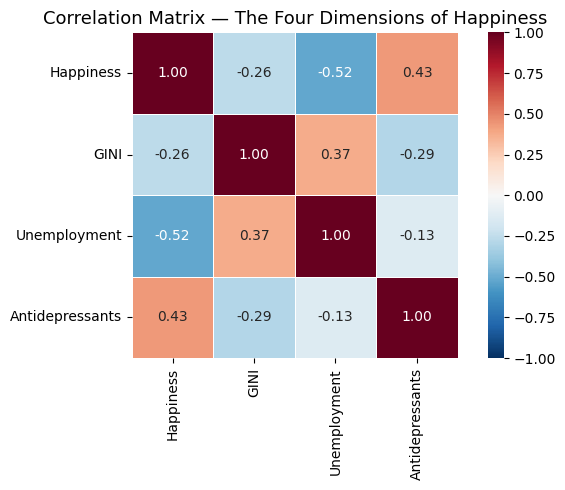

In [176]:
import matplotlib.pyplot as plt
import seaborn as sns

METRICS = ["Happiness", "GINI", "Unemployment", "Antidepressants"]

# ── Correlation matrix heatmap ──────────────────────────────
corr = df[METRICS].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
)
ax.set_title("Correlation Matrix — The Four Dimensions of Happiness", fontsize=13)
plt.tight_layout()
plt.show()

### Distribution of each metric

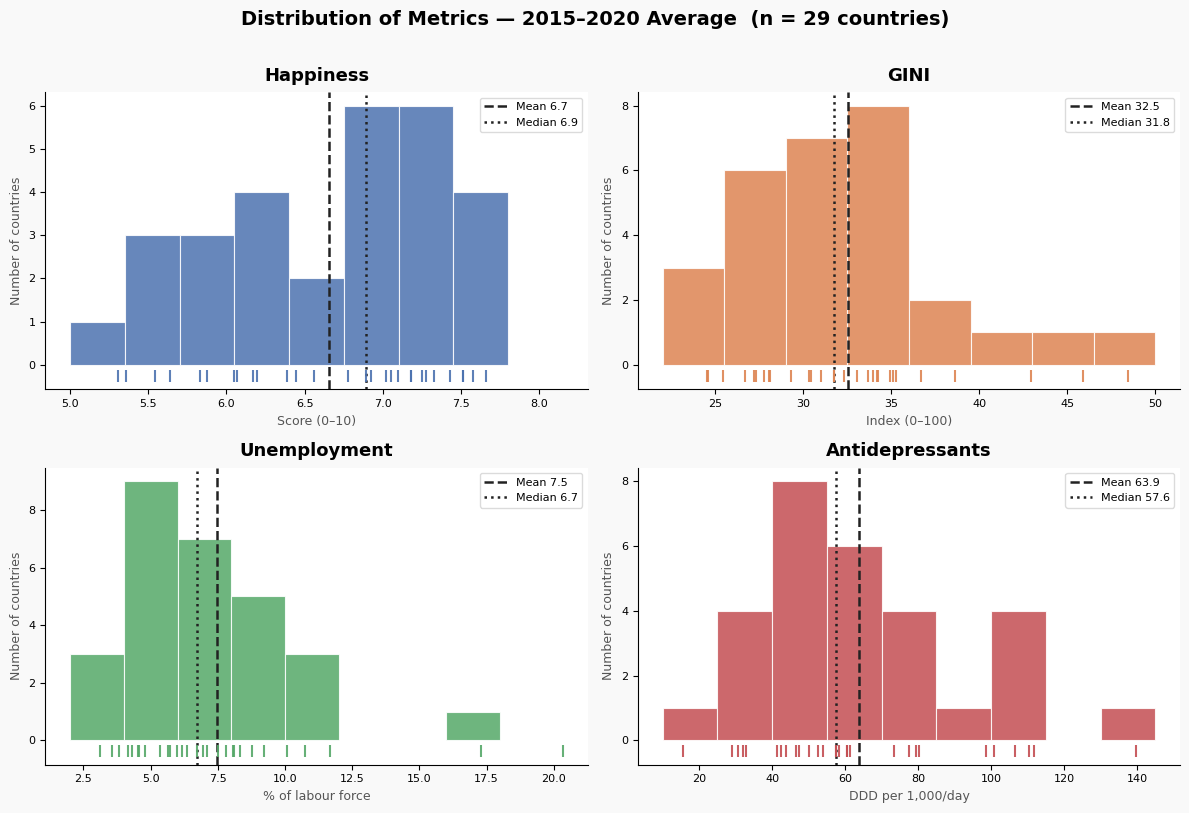

In [177]:
# ── Distribution histograms (2 × 2 grid) ────────────────────
METRIC_UNITS = ["Score (0–10)", "Index (0–100)", "% of labour force", "DDD per 1,000/day"]
METRIC_BINS  = [
    np.arange(5.0,  8.3, 0.35),   # Happiness  (range ~2.4)
    np.arange(22,   52,  3.5),    # GINI       (range ~26)
    np.arange(2,    22,  2.0),    # Unemployment (range ~18)
    np.arange(10,  150, 15.0),    # Antidepressants (range ~124)
]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.patch.set_facecolor("#f9f9f9")

for ax, col, color, unit, bins in zip(axes.flat, METRICS, colors, METRIC_UNITS, METRIC_BINS):
    # Bars — no KDE / trend line
    ax.hist(df[col], bins=bins, color=color, edgecolor="white", linewidth=0.8, alpha=0.85)

    # Mean and median reference lines
    mean_val   = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val,   color="#222", linewidth=1.8, linestyle="--",
               label=f"Mean {mean_val:.1f}")
    ax.axvline(median_val, color="#222", linewidth=1.8, linestyle=":",
               label=f"Median {median_val:.1f}")

    # Rug ticks at the bottom showing individual country values
    ymax = ax.get_ylim()[1]
    ax.plot(df[col], np.full(len(df), -ymax * 0.04),
            "|", color=color, alpha=0.9, markersize=8, markeredgewidth=1.5,
            clip_on=False)

    ax.set_title(col, fontsize=13, fontweight="bold", pad=8)
    ax.set_xlabel(unit, fontsize=9, color="#555")
    ax.set_ylabel("Number of countries", fontsize=9, color="#555")
    ax.set_facecolor("white")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, framealpha=0.7, loc="upper right")

fig.suptitle("Distribution of Metrics — 2015–2020 Average  (n = 29 countries)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### GINI vs. Happiness

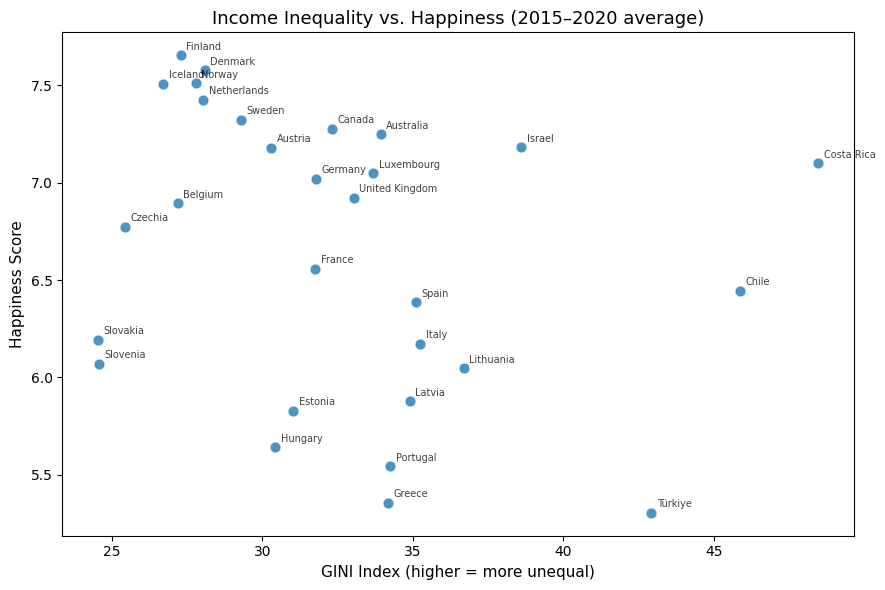

In [178]:
# ── Scatter: GINI vs Happiness ───────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df["GINI"], df["Happiness"], s=60, alpha=0.8, edgecolors="white", linewidth=0.5)

# Label each point with the country name
for _, row in df.iterrows():
    ax.annotate(
        row["Country"], (row["GINI"], row["Happiness"]),
        fontsize=7, alpha=0.75,
        xytext=(4, 4), textcoords="offset points",
    )

ax.set_xlabel("GINI Index (higher = more unequal)", fontsize=11)
ax.set_ylabel("Happiness Score", fontsize=11)
ax.set_title("Income Inequality vs. Happiness (2015–2020 average)", fontsize=13)
plt.tight_layout()
plt.show()

### Scatter plot matrix (pairplot)

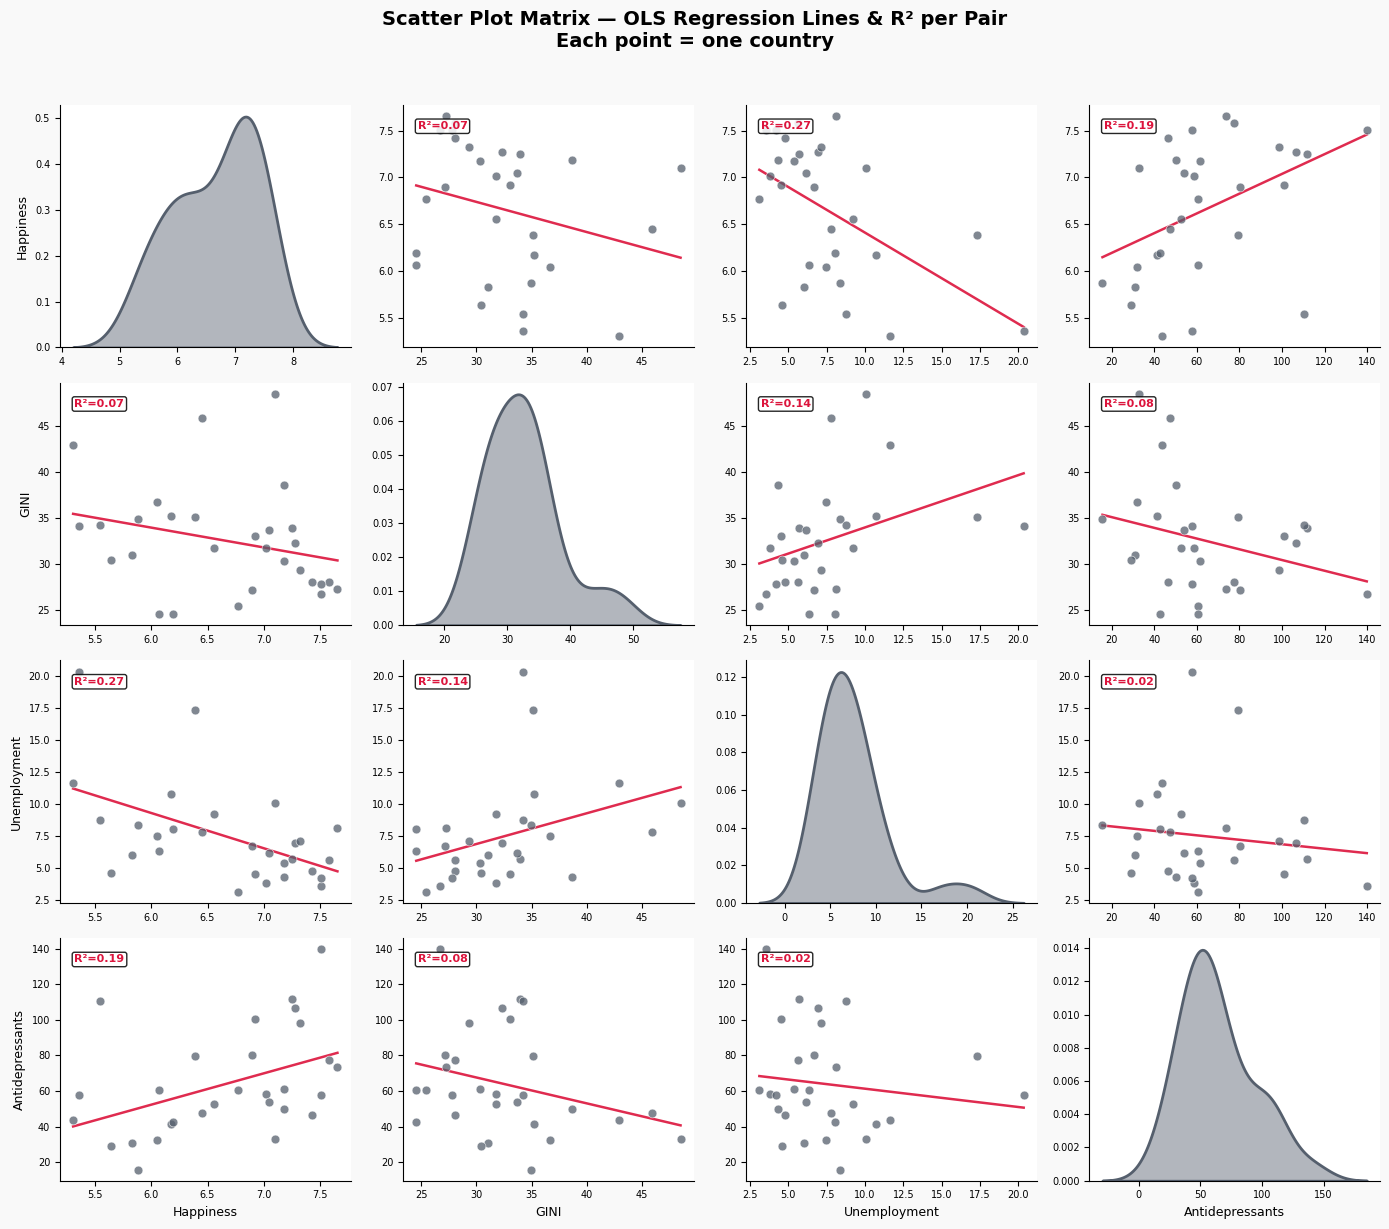

In [179]:
from scipy import stats

POINT_COLOR = "#555F6D"  # uniform neutral colour for all scatter points

n = len(METRICS)
fig_sm, axes_sm = plt.subplots(n, n, figsize=(14, 12))
fig_sm.patch.set_facecolor("#f9f9f9")

for i, row_m in enumerate(METRICS):
    for j, col_m in enumerate(METRICS):
        ax = axes_sm[i, j]
        ax.set_facecolor("white")
        ax.spines[["top", "right"]].set_visible(False)

        if i == j:
            # Diagonal: KDE coloured by this metric
            sns.kdeplot(df[row_m], ax=ax, color=POINT_COLOR,
                        fill=True, alpha=0.45, linewidth=2)
        else:
            x_vals = df[col_m].values
            y_vals = df[row_m].values

            # Uniform neutral colour for all points
            ax.scatter(x_vals, y_vals, c=POINT_COLOR,
                       alpha=0.75, s=40, edgecolors="white", linewidth=0.5,
                       zorder=3)

            # OLS regression line — solid crimson
            slope, intercept, r_val, p_val, _ = stats.linregress(x_vals, y_vals)
            x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
            ax.plot(x_line, slope * x_line + intercept,
                    color="crimson", linewidth=1.8, linestyle="-", alpha=0.9, zorder=2)

            # R² label — no significance stars
            ax.text(0.05, 0.90, f"R²={r_val**2:.2f}",
                    transform=ax.transAxes, fontsize=8, color="crimson",
                    fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85))

        # Axis labels on outer edges only
        ax.set_xlabel(col_m if i == n - 1 else "", fontsize=9)
        ax.set_ylabel(row_m if j == 0 else "", fontsize=9)
        ax.tick_params(labelsize=7)

# Metric diagonal legend only
metric_handles = [
    plt.Line2D([0], [0], color=POINT_COLOR, linewidth=4,
               alpha=0.6, label=m)
    for m in METRICS
]

fig_sm.suptitle(
    "Scatter Plot Matrix — OLS Regression Lines & R² per Pair\n"
    "Each point = one country",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

# 3. Data Analysis — Machine Learning

## 3.1 — Clustering: "Archetypes of Happiness"

We use **K-Means clustering** on the four standardised variables to discover natural groupings of countries. An **elbow plot** helps decide whether 3 or 4 clusters is most appropriate, and **PCA** reduces the feature space to 2-D for visualisation.

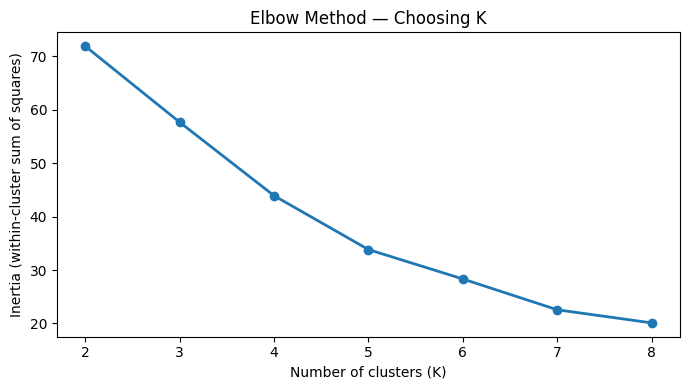

In [180]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ── Normalise features ──────────────────────────────────────
scaler = StandardScaler()
X = df[METRICS].values
X_scaled = scaler.fit_transform(X)

# ── Elbow method: test K = 2..8 ─────────────────────────────
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, "o-", linewidth=2)
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Inertia (within-cluster sum of squares)")
ax.set_title("Elbow Method — Choosing K")
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.show()

PCA explained variance: PC1=50.4%, PC2=21.8%, Total=72.2%


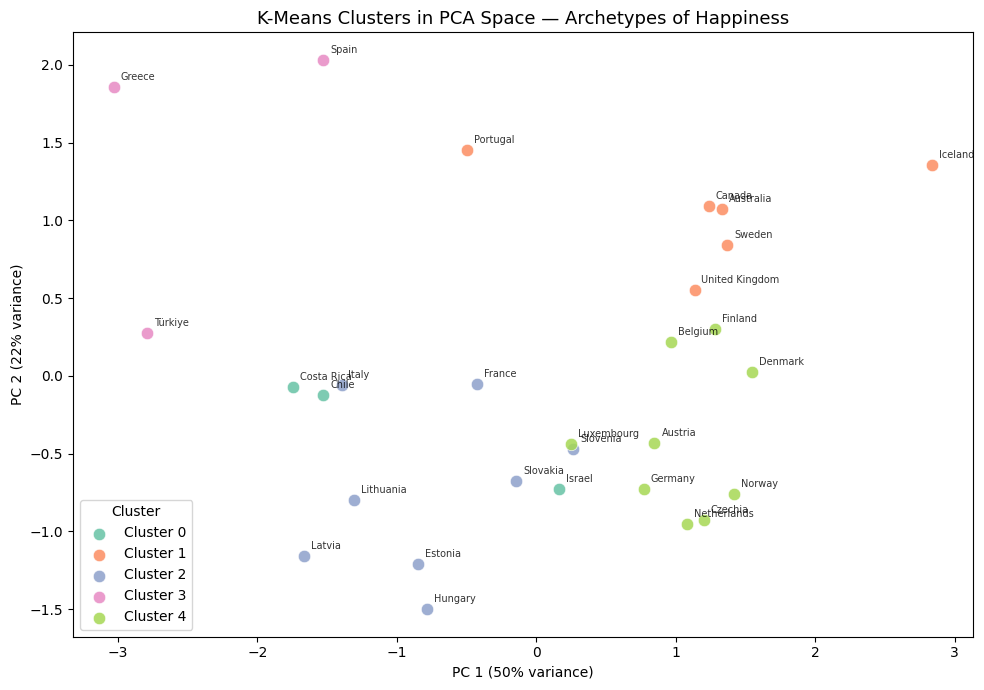

In [181]:
# ── Fit K-Means with chosen K ────────────────────────────────
K = 5  # Adjust after inspecting the elbow plot
km = KMeans(n_clusters=K, n_init=10, random_state=42)
df["Cluster"] = km.fit_predict(X_scaled)

# ── PCA to 2 dimensions ─────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
df["PC1"] = coords[:, 0]
df["PC2"] = coords[:, 1]

print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"Total={sum(pca.explained_variance_ratio_):.1%}")

# ── Plot clusters in PCA space ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette("Set2", K)

for cluster_id in range(K):
    mask = df["Cluster"] == cluster_id
    ax.scatter(
        df.loc[mask, "PC1"], df.loc[mask, "PC2"],
        label=f"Cluster {cluster_id}", s=80, alpha=0.85,
        color=palette[cluster_id], edgecolors="white", linewidth=0.5,
    )
    for _, row in df[mask].iterrows():
        ax.annotate(
            row["Country"], (row["PC1"], row["PC2"]),
            fontsize=7, alpha=0.8, xytext=(5, 5), textcoords="offset points",
        )

ax.set_xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]:.0%} variance)")
ax.set_ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]:.0%} variance)")
ax.set_title("K-Means Clusters in PCA Space — Archetypes of Happiness", fontsize=13)
ax.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [182]:
# ── Cluster summary table ────────────────────────────────────
cluster_summary = df.groupby("Cluster")[METRICS].mean().round(2)
cluster_summary["Count"] = df.groupby("Cluster")["Country"].count().values
print("=== Cluster Averages ===")
display(cluster_summary)

# Countries per cluster
print("\n=== Countries per Cluster ===")
for cid in sorted(df["Cluster"].unique()):
    countries = sorted(df[df["Cluster"] == cid]["Country"].tolist())
    print(f"\nCluster {cid} ({len(countries)} countries): {', '.join(countries)}")

=== Cluster Averages ===


,Happiness,GINI,Unemployment,Antidepressants,Count
Cluster,,,,,
0,6.91,44.31,7.40,43.44,3
1,6.97,31.59,6.10,111.27,6
2,6.05,31.14,7.59,38.07,8
3,5.68,37.39,16.43,60.26,3
4,7.23,28.84,5.32,63.31,9



=== Countries per Cluster ===

Cluster 0 (3 countries): Chile, Costa Rica, Israel

Cluster 1 (6 countries): Australia, Canada, Iceland, Portugal, Sweden, United Kingdom

Cluster 2 (8 countries): Estonia, France, Hungary, Italy, Latvia, Lithuania, Slovakia, Slovenia

Cluster 3 (3 countries): Greece, Spain, Türkiye

Cluster 4 (9 countries): Austria, Belgium, Czechia, Denmark, Finland, Germany, Luxembourg, Netherlands, Norway


## 3.2 — Temporal Interactive Visualizations

Instead of only looking at 5-year averages, we now unfold the **year-by-year** data (2015–2020) to check whether the paradox patterns are stable over time or driven by a single outlier year.

Four complementary interactive charts are produced, each telling a different facet of the story:
1. **Animated scatter** — does the antidepressant–happiness correlation persist each year?
2. **Trajectory lines** — how did each country's happiness evolve?
3. **Bump chart** — did the ranking of countries change dramatically?
4. **Choropleth map** — where in the world is this paradox visible?

In [183]:
import plotly.express as px

# ── Build year-level dataset for the 29 retained countries ───
retained    = set(df["Country"].tolist())
cluster_map = df.set_index("Country")["Cluster"].to_dict()

t_hap  = df_hap[df_hap["Country_std"].isin(retained)][["Country_std","Year","Happiness"]].copy()
t_gini = df_gini[df_gini["Country_std"].isin(retained)][["Country_std","Year","GINI"]].copy()
t_unem = df_unem[df_unem["Country_std"].isin(retained)][["Country_std","Year","Unemployment"]].copy()
t_anti = df_anti[df_anti["Country_std"].isin(retained)][["Country_std","Year","Antidepressants"]].copy()

# Outer merge — keeps all year entries even if some metrics have gaps
df_t = (
    t_hap
    .merge(t_gini, on=["Country_std","Year"], how="outer")
    .merge(t_unem, on=["Country_std","Year"], how="outer")
    .merge(t_anti, on=["Country_std","Year"], how="outer")
)
df_t.rename(columns={"Country_std": "Country"}, inplace=True)
df_t["Cluster"]       = df_t["Country"].map(cluster_map).astype(int)
df_t["Cluster_label"] = "Cluster " + df_t["Cluster"].astype(str)
df_t = df_t.sort_values(["Country","Year"]).reset_index(drop=True)

# Complete-cases subset (all 4 metrics present) for animated charts
df_tc = df_t.dropna(subset=["Happiness","GINI","Unemployment","Antidepressants"]).copy()

print(f"Full temporal  : {len(df_t)} rows | {df_t['Country'].nunique()} countries")
print(f"Complete cases : {len(df_tc)} rows")
print(f"Years covered  : {sorted(df_t['Year'].unique())}")

Full temporal  : 174 rows | 29 countries
Complete cases : 160 rows
Years covered  : [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


### Chart 1 — Animated Scatter: Does the Paradox Persist Each Year?

Each frame is a single year. If the positive antidepressant–happiness relationship is visible in every frame, the paradox is structural rather than an averaging artefact.

In [184]:
# Animated scatter: Happiness vs Antidepressants, year by year
# Bubble size = Unemployment  ·  Colour = cluster  ·  Text = country name

fig_anim = px.scatter(
    df_tc.sort_values("Year"),
    x="Antidepressants",
    y="Happiness",
    animation_frame="Year",
    animation_group="Country",
    size="Unemployment",
    color="Cluster_label",
    text="Country",                # country name shown on each bubble
    hover_name="Country",
    hover_data={
        "GINI": ":.1f",
        "Unemployment": ":.1f",
        "Antidepressants": ":.1f",
        "Cluster_label": False,
        "Year": False,
    },
    color_discrete_sequence=cluster_colors[:K],
    size_max=35,
    title=(
        "Does the Paradox Persist? Antidepressant Use vs Happiness (2015–2020)<br>"
        "<sup>Bubble size = Unemployment rate  ·  Press ▶ to animate through years</sup>"
    ),
    labels={
        "Antidepressants": "Antidepressants (DDD per 1,000 per day)",
        "Happiness": "Happiness Score",
        "Cluster_label": "Cluster",
    },
    template="plotly_white",
    width=950,
    height=640,
)

# Show text labels on all frames
fig_anim.update_traces(textposition="top center", textfont_size=8, mode="markers+text")

# Fix axis ranges so bubbles don't jump around between frames
fig_anim.update_layout(
    xaxis=dict(range=[df_tc["Antidepressants"].min() - 5, df_tc["Antidepressants"].max() + 5]),
    yaxis=dict(range=[df_tc["Happiness"].min() - 0.3,     df_tc["Happiness"].max() + 0.3]),
    # Horizontal legend just below the subtitle, above the plot
    legend=dict(
        title_text="Cluster",
        orientation="h",
        x=0.5, xanchor="center",
        y=1.06, yanchor="bottom",
        font=dict(size=9),
    ),
    margin=dict(t=130, b=100),
)

fig_anim.show()
fig_anim.write_html("./docs/visualizations/happiness_animated.html", include_plotlyjs="cdn")
print("Saved → ./docs/visualizations/happiness_animated.html")

Saved → ./docs/visualizations/happiness_animated.html


### Chart 3 — Bump Chart: Happiness Rankings Over Time

A bump chart shows *relative* position. Countries whose rank is stable across 6 years confirm that the cluster structure is persistent — not a snapshot artifact.

In [190]:
import plotly.graph_objects as go

# Rank within the retained 29 countries each year (1 = happiest)
df_rank = df_t[df_t["Happiness"].notna()].copy()
df_rank["Rank"] = (
    df_rank.groupby("Year")["Happiness"]
    .rank(ascending=False, method="min")
    .astype(int)
)

years            = sorted(df_rank["Year"].unique())
countries_list   = sorted(df_rank["Country"].unique())
country_cluster  = df_rank.groupby("Country")["Cluster"].first().to_dict()
cluster_legend_added = set()

fig_bump = go.Figure()

# ── Initial traces: show only the first year ─────────────────
for country in countries_list:
    cid        = country_cluster[country]
    cdata_full = df_rank[df_rank["Country"] == country].sort_values("Year")
    cdata_y0   = cdata_full[cdata_full["Year"] == years[0]]

    show_legend = cid not in cluster_legend_added
    if show_legend:
        cluster_legend_added.add(cid)

    x0 = cdata_y0["Year"].tolist()
    y0 = cdata_y0["Rank"].tolist()

    fig_bump.add_trace(go.Scatter(
        x=x0,
        y=y0,
        mode="lines+markers+text",
        name=f"Cluster {cid}",
        legendgroup=f"Cluster {cid}",
        showlegend=show_legend,
        line=dict(color=cluster_colors[cid], width=2.5),
        marker=dict(size=8, color=cluster_colors[cid], symbol="circle"),
        text=[country] if x0 else [],
        textposition="middle right",
        textfont=dict(size=8, color="#333"),
        hovertemplate=(
            f"<b>{country}</b><br>"
            "Year: %{x}<br>Rank: %{y}<extra></extra>"
        ),
    ))

# ── Frames: progressively reveal each year ───────────────────
frames = []
for yr in years:
    frame_data = []
    for country in countries_list:
        cdata      = df_rank[df_rank["Country"] == country].sort_values("Year")
        cdata_upto = cdata[cdata["Year"] <= yr]

        x_vals = cdata_upto["Year"].tolist()
        y_vals = cdata_upto["Rank"].tolist()
        # Country name shown only at the rightmost visible point
        text_labels = [""] * len(x_vals)
        if text_labels:
            text_labels[-1] = country

        frame_data.append(go.Scatter(x=x_vals, y=y_vals, text=text_labels))

    frames.append(go.Frame(data=frame_data, name=str(yr)))

fig_bump.frames = frames

fig_bump.update_layout(
    title=dict(
        text=(
            "Happiness Rankings 2015–2020 — Bump Chart<br>"
            "<sup>Rank 1 = happiest  ·  Press ▶ to animate through years</sup>"
        ),
        x=0.5,
    ),
    xaxis=dict(title="Year", tickvals=years, range=[years[0] - 0.3, years[-1] + 1.3]),
    yaxis=dict(
        title="Rank (1 = happiest)",
        autorange="reversed",
        dtick=1,
        gridcolor="#e8e8e8",
        tickfont=dict(size=10),
    ),
    template="plotly_white",
    width=950,
    height=900,
    legend=dict(
        orientation="h",
        x=0.5, xanchor="center",
        y=1.0, yanchor="bottom",
        title_text="Cluster",
        font=dict(size=9),
        tracegroupgap=5,
    ),
    margin=dict(r=50, t=120, b=120),
    # Play / Pause buttons
    updatemenus=[dict(
        type="buttons",
        buttons=[
            dict(
                label="▶ Play",
                method="animate",
                args=[None, dict(
                    frame=dict(duration=700, redraw=True),
                    fromcurrent=True,
                    transition=dict(duration=300),
                )],
            ),
            dict(
                label="⏸ Pause",
                method="animate",
                args=[[None], dict(
                    frame=dict(duration=0, redraw=False),
                    mode="immediate",
                    transition=dict(duration=0),
                )],
            ),
        ],
        direction="left",
        pad=dict(r=10, t=5),
        showactive=False,
        x=0.0, xanchor="left",
        y=-0.12, yanchor="top",
    )],
    # Year slider
    sliders=[dict(
        active=0,
        steps=[dict(
            method="animate",
            args=[[str(yr)], dict(
                mode="immediate",
                frame=dict(duration=600, redraw=True),
                transition=dict(duration=200),
            )],
            label=str(yr),
        ) for yr in years],
        x=0.15, len=0.85,
        y=-0.10,
        currentvalue=dict(prefix="Year: ", visible=True, xanchor="center"),
        transition=dict(duration=200),
    )],
)

fig_bump.show()
fig_bump.write_html("./docs/visualizations/happiness_bump.html", include_plotlyjs="cdn")
print("Saved → ./docs/visualizations/happiness_bump.html")

Saved → ./docs/visualizations/happiness_bump.html


### Chart 4 — Geographic View: Plotly Choropleth

Does the paradox cluster geographically? Toggle between the happiness map and the antidepressant map to see if the same countries light up.

In [186]:
# Get ISO alpha-3 codes (needed by Plotly choropleth)
def get_iso3(name):
    try:
        return pycountry.countries.lookup(name).alpha_3
    except LookupError:
        return None

df_map = df[["Country","Happiness","Antidepressants","GINI","Unemployment","Cluster"]].copy()
df_map["ISO_A3"] = df_map["Country"].apply(get_iso3)
df_map.dropna(subset=["ISO_A3"], inplace=True)

# Two traces — one per metric — toggled via buttons
fig_geo = go.Figure()

fig_geo.add_trace(go.Choropleth(
    locations=df_map["ISO_A3"],
    z=df_map["Happiness"],
    text=df_map["Country"],
    hovertemplate="<b>%{text}</b><br>Happiness: %{z:.2f}<extra></extra>",
    colorscale="YlGn",
    zmin=5, zmax=8,
    colorbar=dict(title="Score", x=1.02),
    visible=True,
    name="Happiness",
))

fig_geo.add_trace(go.Choropleth(
    locations=df_map["ISO_A3"],
    z=df_map["Antidepressants"],
    text=df_map["Country"],
    hovertemplate="<b>%{text}</b><br>Antidepressants: %{z:.1f} DDD/1k/day<extra></extra>",
    colorscale="OrRd",
    colorbar=dict(title="DDD/1k/day", x=1.02),
    visible=False,
    name="Antidepressants",
))

fig_geo.update_layout(
    title=dict(
        text=(
            "The Paradox Visualised Geographically<br>"
            "<sup>Toggle to see if the same countries score high on both maps</sup>"
        ),
        x=0.5,
        y=0.97,
    ),
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type="natural earth",
        showcountries=True,
    ),
    updatemenus=[dict(
        type="buttons",
        direction="right",
        x=0.5, xanchor="center",
        y=1.09, yanchor="top",      # positioned at the top
        pad=dict(r=5, t=4, b=4, l=5),
        font=dict(size=11),          # smaller button text
        buttons=[
            dict(
                label="Happiness Score",
                method="update",
                args=[{"visible": [True, False]}],
            ),
            dict(
                label="Antidepressant Use",
                method="update",
                args=[{"visible": [False, True]}],
            ),
        ],
        showactive=True,
        bgcolor="white",
        bordercolor="#aaa",
        borderwidth=1,
    )],
    width=950,
    height=530,
    template="plotly_white",
    margin=dict(t=105, r=80),
)

fig_geo.show()
fig_geo.write_html("./docs/visualizations/happiness_geo.html", include_plotlyjs="cdn")
print("Saved → ./docs/visualizations/happiness_geo.html")

Saved → ./docs/visualizations/happiness_geo.html


### Chart 5 — Who Got Happier? Folium Map of Happiness Change 2015→2020

While the choropleth above shows *average* scores, this map asks: **did things actually improve?**  
Each circle represents one country: **green** if happiness rose, **red** if it fell.  
Circle size reflects the magnitude of change. Click any marker for full details.

In [187]:
import folium

# -- Compute happiness change 2015 -> 2020
hap_2015 = (
    df_t[df_t['Year'] == 2015][['Country', 'Happiness']]
    .dropna().set_index('Country')['Happiness']
)
hap_2020 = (
    df_t[df_t['Year'] == 2020][['Country', 'Happiness']]
    .dropna().set_index('Country')['Happiness']
)
common   = hap_2015.index.intersection(hap_2020.index)
df_delta = pd.DataFrame({
    'Country':        common,
    'Happiness_2015': hap_2015[common].values,
    'Happiness_2020': hap_2020[common].values,
    'Delta':          (hap_2020[common] - hap_2015[common]).values,
})

# Approximate lat/lon for the retained countries
CHANGE_COORDS = {
    'Australia':               (-25.3,  133.8),
    'Austria':                 ( 47.5,   14.6),
    'Belgium':                 ( 50.5,    4.5),
    'Canada':                  ( 56.1, -106.3),
    'Czechia':                 ( 49.8,   15.5),
    'Denmark':                 ( 56.3,    9.5),
    'Estonia':                 ( 58.6,   25.0),
    'Finland':                 ( 61.9,   25.7),
    'France':                  ( 46.2,    2.2),
    'Germany':                 ( 51.2,   10.5),
    'Greece':                  ( 39.1,   21.8),
    'Hungary':                 ( 47.2,   19.5),
    'Iceland':                 ( 64.9,  -19.0),
    'Ireland':                 ( 53.4,   -8.2),
    'Israel':                  ( 31.0,   35.0),
    'Italy':                   ( 41.9,   12.6),
    'Japan':                   ( 36.2,  138.3),
    'Korea, Republic of':      ( 36.5,  127.9),
    'Latvia':                  ( 56.9,   24.6),
    'Lithuania':               ( 55.2,   23.9),
    'Luxembourg':              ( 49.8,    6.1),
    'Netherlands':             ( 52.3,    5.3),
    'New Zealand':             (-40.9,  174.9),
    'Norway':                  ( 60.5,    8.5),
    'Poland':                  ( 51.9,   19.1),
    'Portugal':                ( 39.4,   -8.2),
    'Slovakia':                ( 48.7,   19.7),
    'Slovenia':                ( 46.2,   15.0),
    'Spain':                   ( 40.5,   -3.7),
    'Sweden':                  ( 60.1,   18.6),
    'Switzerland':             ( 46.8,    8.2),
    'United Kingdom':          ( 55.4,   -3.4),
    'United States':           ( 37.1,  -95.7),
    'Turkiye':                 ( 38.9,   35.2),
    'T\u00fcrkiye':             ( 38.9,   35.2),
}

max_abs = df_delta['Delta'].abs().max()
m_change = folium.Map(location=[50, 15], zoom_start=3, tiles='CartoDB positron')

for _, row in df_delta.iterrows():
    coords = CHANGE_COORDS.get(row['Country'])
    if coords is None:
        continue
    delta  = row['Delta']
    color  = '#27AE60' if delta >= 0 else '#E74C3C'
    radius = max(6, abs(delta) / max_abs * 28)
    sign   = '+' if delta >= 0 else ''
    popup_html = (
        f"<b style='font-size:13px'>{row['Country']}</b><br>"
        f"2015: {row['Happiness_2015']:.2f}<br>"
        f"2020: {row['Happiness_2020']:.2f}<br>"
        f"<span style='color:{color};font-weight:bold'>Change: {sign}{delta:.2f}</span>"
    )
    folium.CircleMarker(
        location=coords,
        radius=radius,
        color='white', weight=1.5,
        fill=True, fill_color=color, fill_opacity=0.88,
        popup=folium.Popup(popup_html, max_width=200),
        tooltip=f"{row['Country']}: {sign}{delta:.2f}",
    ).add_to(m_change)

legend_html = (
    '<div style="position:fixed;bottom:30px;left:30px;z-index:9999;'
    'background:white;padding:12px 16px;border-radius:8px;'
    'border:1px solid #ccc;font-family:sans-serif;font-size:12px;">'
    '<b>Happiness Change 2015&#8594;2020</b><br>'
    '<span style="color:#27AE60;font-size:16px;">&#9679;</span> Increased &nbsp;'
    '<span style="color:#E74C3C;font-size:16px;">&#9679;</span> Decreased<br>'
    '<span style="color:#888">Circle size = magnitude of change</span></div>'
)
m_change.get_root().html.add_child(folium.Element(legend_html))

import os; os.makedirs('./docs/visualizations', exist_ok=True)
change_path = './docs/visualizations/happiness_change_map.html'
m_change.save(change_path)
print(f'Saved -> {change_path}')
m_change


Saved -> ./docs/visualizations/happiness_change_map.html


# 4. Genre — Visual Narrative & Narrative Structure

*TODO: Discuss which of Segel & Heer's categories (Magazine Style, Annotated Chart, Partitioned Poster, Flow Chart, Comic Strip, Slide Show, Film/Video/Animation) apply to your narrative visualization, and which narrative structure elements (Martini Glass, Interactive Slideshow, Drill-Down Story) you used and why.*

# 5. Visualizations — Interactive Narrative (Plotly)

Following the **Martini Glass** structure (Segel & Heer, 2010), we present a single author-driven insight — *"happy countries consume more antidepressants"* — and then hand control to the reader via a **dropdown menu** that lets them swap the x-axis between Unemployment Rate and GINI Index.

*TODO: Add justification of chart choices (bubble chart, colour encoding, size encoding) here.*

In [188]:
import plotly.graph_objects as go

# ── Prepare data for the bubble chart ────────────────────────
cluster_labels = {c: f"Cluster {c}" for c in sorted(df["Cluster"].unique())}
df["Cluster_label"] = df["Cluster"].map(cluster_labels)

# cluster_colors is defined in the setup cell at the top

x_options = {
    "Unemployment Rate (%)": df["Unemployment"].values,
    "GINI Index":            df["GINI"].values,
}

fig = go.Figure()

for cid in sorted(df["Cluster"].unique()):
    mask = df["Cluster"] == cid
    sub  = df[mask]

    hover = [
        f"<b>{row['Country']}</b><br>"
        f"Happiness: {row['Happiness']:.2f}<br>"
        f"Unemployment: {row['Unemployment']:.1f}%<br>"
        f"GINI: {row['GINI']:.1f}<br>"
        f"Antidepressants: {row['Antidepressants']:.1f} DDD/1k/day"
        for _, row in sub.iterrows()
    ]

    fig.add_trace(go.Scatter(
        x=sub["Unemployment"],
        y=sub["Happiness"],
        mode="markers+text",
        text=sub["Country"],
        textposition="top center",
        textfont=dict(size=8),
        marker=dict(
            size=sub["Antidepressants"] / 4,
            color=cluster_colors[cid],
            opacity=0.75,
            line=dict(width=1, color="white"),
            sizemin=5,
        ),
        name=f"Cluster {cid}",
        hovertext=hover,
        hoverinfo="text",
    ))

# ── Dropdown menu to swap X-axis ─────────────────────────────
buttons = []
for label, x_values in x_options.items():
    x_per_trace = []
    for cid in sorted(df["Cluster"].unique()):
        mask = df["Cluster"] == cid
        x_per_trace.append(x_values[mask.values])

    buttons.append(dict(
        label=label,
        method="update",
        args=[
            {"x": x_per_trace},
            {"xaxis.title.text": label},
        ],
    ))

fig.update_layout(
    title=dict(
        text="The Paradox of Happiness<br>"
             "<sup>Bubble size = Antidepressant consumption (DDD per 1,000 people/day) · "
             "Colour = K-Means cluster</sup>",
        x=0.5,
    ),
    xaxis_title="Unemployment Rate (%)",
    yaxis_title="Happiness Score (Life Evaluation, 0–10)",
    # Horizontal legend just below the subtitle
    legend=dict(
        orientation="h",
        x=0.5, xanchor="center",
        y=1.06, yanchor="bottom",
        title_text="Cluster",
        font=dict(size=9),
    ),
    updatemenus=[dict(
        type="dropdown",
        direction="down",
        x=0.0, xanchor="left",
        y=1.18, yanchor="top",
        buttons=buttons,
        showactive=True,
        bgcolor="white",
        bordercolor="#ccc",
    )],
    template="plotly_white",
    width=950,
    height=680,
    margin=dict(t=150),
)

fig.show()

In [189]:
# ── Export interactive chart as standalone HTML ───────────────
import os
os.makedirs("./docs/visualizations", exist_ok=True)
output_path = "./docs/visualizations/happiness_bubble.html"
fig.write_html(output_path, include_plotlyjs="cdn")
print(f"Saved interactive chart → {output_path}")

Saved interactive chart → ./docs/visualizations/happiness_bubble.html


# 6. Discussion

*TODO: What went well? What is missing? Potential improvements? Limitations (e.g. antidepressant data is OECD-only, limiting the sample to developed nations; GINI data has gaps in some years).*

# 7. Contributions

*TODO: Group member breakdown — who did what.*

# 8. References

*TODO: Add academic citations (Segel & Heer 2010, World Happiness Report, World Bank, OECD, etc.)*